# Minimal RuleTreeRank Example

This notebook uses `load_diabetes` from `sklearn.datasets` to show the two-stage behavior of `RuleTreeRank`:

1. **Stage 1**: a shallow `RuleTreeRegressor` produces an interpretable score and assigns each instance to a leaf.
2. **Stage 2**: inside each leaf, a `PairwiseDistanceTree` learns a distance over residuals and a local k-NN predicts a correction.

The diabetes dataset is not a native Learning-to-Rank dataset. For this minimal example, we create synthetic query groups from quantiles of the `bmi` feature; they satisfy the `fit(X, y, q)` interface and make the grouped structure visible.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "ruletreerank").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from RuleTree import RuleTreeRegressor
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from ltr_utility import ModelParam
from ruletreerank import KNNRegFast, PairwiseDistanceTree, RuleTreeRank

pd.set_option("display.max_columns", 20)
RANDOM_STATE = 1

## 1. sklearn Dataset And Synthetic Queries

We load the dataset from scikit-learn and build `query_group` by splitting `bmi` into 6 quantiles. In a real LTR dataset, `q` would come from the dataset itself; here it is a compact structure for the example.

In [2]:
dataset = load_diabetes(as_frame=True)
X_all = dataset.data.copy()
y_all = dataset.target.to_numpy()

q_all = pd.qcut(X_all["bmi"], q=6, labels=False, duplicates="drop").astype(int).to_numpy()
example_df = X_all.assign(target=y_all, query_group=q_all)

query_summary = (
    example_df
    .groupby("query_group")
    .agg(
        n_docs=("target", "size"),
        target_mean=("target", "mean"),
        target_min=("target", "min"),
        target_max=("target", "max"),
        bmi_min=("bmi", "min"),
        bmi_max=("bmi", "max"),
    )
    .round(3)
)

display(example_df.head(8).round(3))
display(query_summary)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,query_group
0,0.038,0.051,0.062,0.022,-0.044,-0.035,-0.043,-0.003,0.020,-0.018,151.0,5
1,-0.002,-0.045,-0.051,-0.026,-0.008,-0.019,0.074,-0.039,-0.068,-0.092,75.0,0
2,0.085,0.051,0.044,-0.006,-0.046,-0.034,-0.032,-0.003,0.003,-0.026,141.0,4
3,-0.089,-0.045,-0.012,-0.037,0.012,0.025,-0.036,0.034,0.023,-0.009,206.0,2
4,0.005,-0.045,-0.036,0.022,0.004,0.016,0.008,-0.003,-0.032,-0.047,135.0,1
5,-0.093,-0.045,-0.041,-0.019,-0.069,-0.079,0.041,-0.076,-0.041,-0.096,97.0,1
6,-0.045,0.051,-0.047,-0.016,-0.040,-0.025,0.001,-0.039,-0.063,-0.038,138.0,0
7,0.064,0.051,-0.002,0.067,0.091,0.109,0.023,0.018,-0.036,0.003,63.0,3


,n_docs,target_mean,target_min,target_max,bmi_min,bmi_max
query_group,,,,,,
0,75,97.947,37.0,252.0,-0.090,-0.046
1,72,114.153,40.0,253.0,-0.045,-0.026
2,76,128.276,25.0,292.0,-0.025,-0.007
3,72,158.236,44.0,311.0,-0.006,0.015
4,74,192.608,52.0,317.0,0.016,0.050
5,73,223.055,55.0,346.0,0.052,0.171


## 2. Fit RuleTreeRank

The model is intentionally small: a base tree with `max_depth=2`, an interpretable distance model with `PairwiseDistanceTree`, and a local k-NN with 5 neighbors. `dist_objective="residuals"` makes explicit that the second stage works on the residuals left by stage 1.

In [3]:
np.random.seed(RANDOM_STATE)
idx = np.arange(len(y_all))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.35,
    random_state=RANDOM_STATE,
    stratify=q_all,
)

# Keep the notebook small and fast while preserving enough examples per leaf.
train_idx = train_idx[:180]
test_idx = test_idx[:80]

X_train = X_all.iloc[train_idx].reset_index(drop=True)
X_test = X_all.iloc[test_idx].reset_index(drop=True)
y_train = y_all[train_idx]
y_test = y_all[test_idx]
q_train = q_all[train_idx]
q_test = q_all[test_idx]

rtr = RuleTreeRank(
    distance_f=ModelParam(PairwiseDistanceTree, {
        "base_regressor": ModelParam(RuleTreeRegressor, {"max_depth": 2, "random_state": RANDOM_STATE}),
        "feature_concat": False,
        "feature_diff": True,
        "feature_sq_diff": True,
        "subsample": 0.35,
        "verbose": False,
    }),
    aggregation_f=ModelParam(KNNRegFast, {"n_neighbors": 5, "n_jobs": 1}),
    base_regressor=RuleTreeRegressor(max_depth=2, random_state=RANDOM_STATE),
    dist_objective="residuals",
    verbose=False,
    n_jobs_leaf=1,
)

rtr.fit(X_train, y_train, q_train)

print(f"Train rows: {len(X_train)}")
print(f"Test rows:  {len(X_test)}")
print(f"Stage-2 leaf models: {len(rtr._leaf_dist_map)}")

Train rows: 180
Test rows:  80
Stage-2 leaf models: 4


## 3. Stage 1 And Local-Model Table

Each stage-1 leaf has its own local model in stage 2. The table combines the residual distribution produced by the base tree with the configuration of the local k-NN trained on that leaf.

In [4]:
X_train_np = X_train.to_numpy()
train_leaf = rtr._shallow_dt.apply(X_train_np)
train_stage1 = rtr._shallow_dt.predict(X_train_np)
train_diag = pd.DataFrame({
    "leaf": train_leaf,
    "target": y_train,
    "stage1_score": train_stage1,
    "residual_after_stage1": y_train - train_stage1,
})

leaf_residuals = (
    train_diag
    .groupby("leaf")
    .agg(
        n_train=("target", "size"),
        target_mean=("target", "mean"),
        stage1_mean=("stage1_score", "mean"),
        residual_mean=("residual_after_stage1", "mean"),
        residual_std=("residual_after_stage1", "std"),
    )
)

stage2_models = pd.DataFrame([
    {
        "leaf": leaf,
        "knn_rows": int(agg._fit_X.shape[0]),
        "n_neighbors": int(agg.n_neighbors),
        "learned_distance": agg.custom_metric_func is not None,
    }
    for leaf, agg in rtr._leaf_dist_map.items()
]).set_index("leaf")

leaf_table = leaf_residuals.join(stage2_models).sort_values("n_train", ascending=False).round(2)
display(leaf_table)

,n_train,target_mean,stage1_mean,residual_mean,residual_std,knn_rows,n_neighbors,learned_distance
leaf,,,,,,,,
Rll,72,89.01,89.01,0.0,41.42,72,5,True
Rlr,51,155.20,155.20,0.0,60.28,51,5,True
Rrr,32,246.56,246.56,0.0,51.60,32,5,True
Rrl,25,173.04,173.04,0.0,74.38,25,5,True


## 4. Prediction Decomposition

`RuleTreeRank.predict(..., output="score")` returns the stage-1 score.
`output="corr"` returns only the local stage-2 correction.
`output="full"` returns the sum of both contributions.

In [5]:
stage1_score = rtr.predict(X_test, q=q_test, output="score")
stage2_correction = rtr.predict(X_test, q=q_test, output="corr")
final_score = rtr.predict(X_test, q=q_test, output="full")
test_leaf = rtr._shallow_dt.apply(X_test.to_numpy())

pred_table = pd.DataFrame({
    "query_group": q_test,
    "leaf": test_leaf,
    "target": y_test,
    "stage1_score": stage1_score,
    "stage2_correction": stage2_correction,
    "final_score": final_score,
    "abs_error_stage1": np.abs(y_test - stage1_score),
    "abs_error_final": np.abs(y_test - final_score),
})

metrics = pd.DataFrame([
    {
        "model_output": "stage 1: shallow RuleTree",
        "MAE": mean_absolute_error(y_test, stage1_score),
        "R2": r2_score(y_test, stage1_score),
    },
    {
        "model_output": "stage 1 + stage 2 correction",
        "MAE": mean_absolute_error(y_test, final_score),
        "R2": r2_score(y_test, final_score),
    },
]).round(3)

display(metrics)
display(pred_table.head(12).round(2))

,model_output,MAE,R2
0,stage 1: shallow RuleTree,49.087,0.379
1,stage 1 + stage 2 correction,48.462,0.386


,query_group,leaf,target,stage1_score,stage2_correction,final_score,abs_error_stage1,abs_error_final
0,1,Rll,146.0,89.01,12.19,101.2,56.99,44.8
1,1,Rlr,152.0,155.20,5.80,161.0,3.20,9.0
2,2,Rll,97.0,89.01,-10.41,78.6,7.99,18.4
3,5,Rrr,258.0,246.56,-11.36,235.2,11.44,22.8
4,5,Rrr,336.0,246.56,-13.16,233.4,89.44,102.6
5,0,Rll,99.0,89.01,-3.81,85.2,9.99,13.8
6,5,Rrl,140.0,173.04,48.16,221.2,33.04,81.2
7,3,Rlr,138.0,155.20,11.20,166.4,17.20,28.4
8,0,Rll,59.0,89.01,15.19,104.2,30.01,45.2
9,0,Rlr,94.0,155.20,-33.80,121.4,61.20,27.4


## 6. Visual View: Residuals Per Leaf And Two-Stage Flow

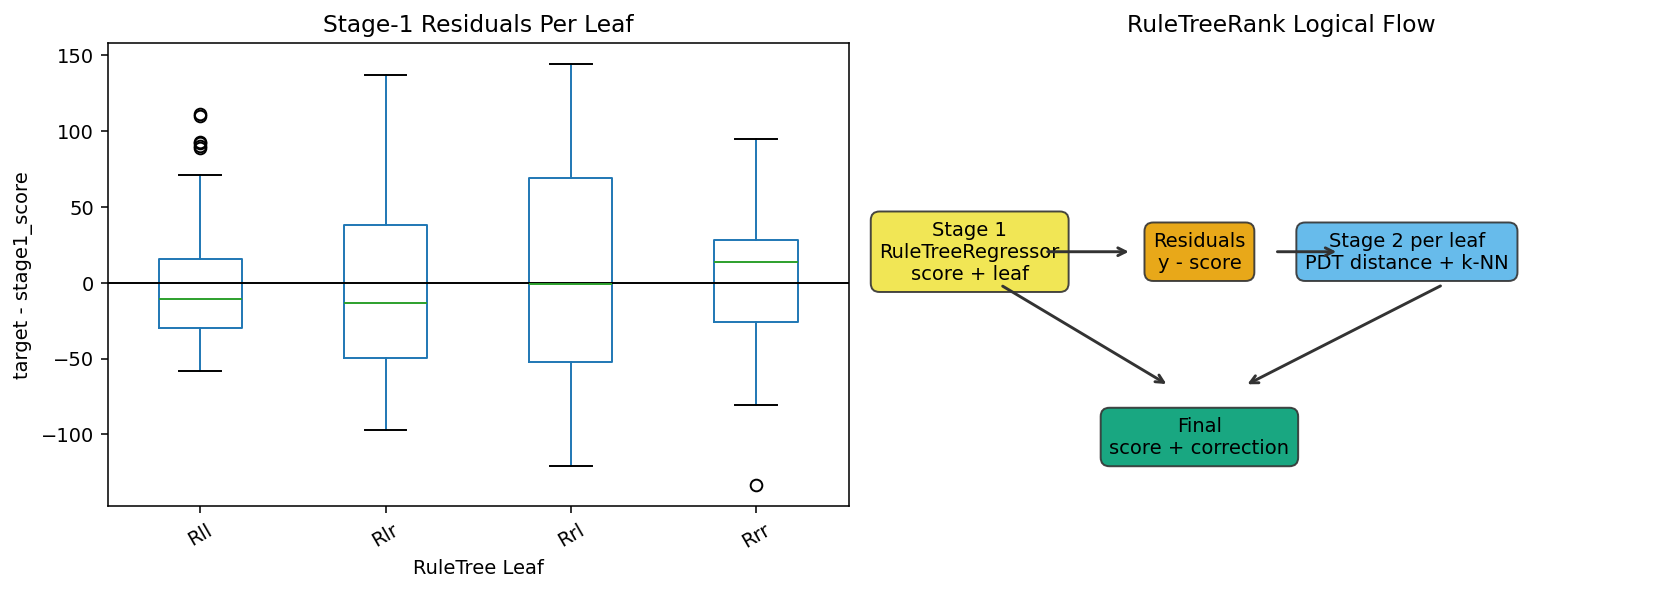

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

train_diag.boxplot(column="residual_after_stage1", by="leaf", ax=axes[0], grid=False, rot=30)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Stage-1 Residuals Per Leaf")
axes[0].set_xlabel("RuleTree Leaf")
axes[0].set_ylabel("target - stage1_score")
fig.suptitle("")

axes[1].axis("off")
boxes = [
    (0.08, 0.55, "Stage 1\nRuleTreeRegressor\nscore + leaf", "#F0E442"),
    (0.39, 0.55, "Residuals\ny - score", "#E69F00"),
    (0.67, 0.55, "Stage 2 per leaf\nPDT distance + k-NN", "#56B4E9"),
    (0.39, 0.15, "Final\nscore + correction", "#009E73"),
]
for x, y, label, color in boxes:
    axes[1].text(
        x, y, label, ha="center", va="center", fontsize=10,
        bbox={"boxstyle": "round,pad=0.45", "facecolor": color, "edgecolor": "#333333", "alpha": 0.9},
        transform=axes[1].transAxes,
    )
arrowprops = {"arrowstyle": "->", "linewidth": 1.5, "color": "#333333"}
axes[1].annotate("", xy=(0.30, 0.55), xytext=(0.18, 0.55), xycoords="axes fraction", arrowprops=arrowprops)
axes[1].annotate("", xy=(0.58, 0.55), xytext=(0.49, 0.55), xycoords="axes fraction", arrowprops=arrowprops)
axes[1].annotate("", xy=(0.45, 0.26), xytext=(0.72, 0.48), xycoords="axes fraction", arrowprops=arrowprops)
axes[1].annotate("", xy=(0.35, 0.26), xytext=(0.12, 0.48), xycoords="axes fraction", arrowprops=arrowprops)
axes[1].set_title("RuleTreeRank Logical Flow")

plt.tight_layout()
plt.show()

## 7. A Single Prediction As The Sum Of Two Stages

This table shows the simplest case to read: the final score is the RuleTree score plus the local correction estimated by the k-NN in the same leaf.

In [8]:
row = pred_table.iloc[0]
single_prediction = pd.DataFrame([
    {"component": "true target", "value": row["target"]},
    {"component": "stage 1 score", "value": row["stage1_score"]},
    {"component": "stage 2 correction", "value": row["stage2_correction"]},
    {"component": "final score", "value": row["final_score"]},
    {"component": "absolute error final", "value": row["abs_error_final"]},
]).round(2)

display(single_prediction)
print(f"query_group={int(row['query_group'])}, leaf={row['leaf']}")

query_group=1, leaf=Rll


,component,value
0,true target,146.00
1,stage 1 score,89.01
2,stage 2 correction,12.19
3,final score,101.20
4,absolute error final,44.80
